# Klasifikasi Sentimen Ulasan Spotify Menggunakan IndoBERT Berbasis Transformer

Notebook ini dibuat untuk proyek akhir mata kuliah Kecerdasan Buatan dengan topik **Transformer**.  
Dataset yang digunakan adalah **Spotify Reviews - Indonesia (Google Play Store)** dari Kaggle.

Tujuan utama notebook:
1. Melakukan preprocessing data ulasan Spotify berbahasa Indonesia.
2. Membuat label sentimen dari rating pengguna.
3. Melatih baseline **TF-IDF + Logistic Regression**.
4. Melatih model utama **IndoBERT**.
5. Menambahkan minimal satu eksperimen tuning IndoBERT.
6. Membandingkan performa model.
7. Melakukan error analysis.
8. Menyediakan fungsi demo prediksi manual.
9. Menyimpan hasil eksperimen, gambar, CSV, dan model.

> Catatan: Label sentimen pada proyek ini diturunkan dari rating. Artinya, hasil klasifikasi bergantung pada asumsi bahwa rating pengguna merepresentasikan sentimen teks ulasan.

## 1. Instalasi Library

Cell ini menginstall library yang dibutuhkan:
- `kagglehub` untuk download dataset dari Kaggle.
- `transformers` untuk memakai IndoBERT.
- `datasets` untuk format dataset Hugging Face.
- `accelerate` untuk membantu training model Transformer.
- `scikit-learn` untuk baseline dan evaluasi.

In [ ]:
# Install library yang dibutuhkan di Google Colab
!pip install kagglehub transformers datasets accelerate evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00


## 2. Import Library dan Setup Awal

Bagian ini memanggil semua library yang diperlukan dan menyiapkan random seed agar hasil eksperimen lebih reproducible.

In [ ]:
import os
import re
import json
import random
import inspect
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

# Folder untuk menyimpan output eksperimen
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Random seed agar hasil split data dan training lebih konsisten
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Cek device yang dipakai: GPU jika tersedia, jika tidak pakai CPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## 3. Download dan Load Dataset dari Kaggle

Dataset diambil menggunakan `kagglehub`. Jika file sudah ada secara lokal, kode ini juga bisa membaca file CSV pertama yang ditemukan pada folder dataset.

Dataset memiliki kolom penting:
- `Ulasan`: teks review pengguna.
- `Rating`: rating pengguna dari 1 sampai 5.

In [ ]:
import kagglehub

# Download dataset Spotify Reviews Indonesia dari Kaggle
path = kagglehub.dataset_download("pandaa12/spotify-reviews-indonesia-google-play-store")
print("Path to dataset files:", path)
print("Files:", os.listdir(path))

# Cari file CSV pada folder dataset
csv_files = [f for f in os.listdir(path) if f.lower().endswith(".csv")]
print("CSV files:", csv_files)

# Load CSV pertama yang ditemukan
file_path = os.path.join(path, csv_files[0])
df_raw = pd.read_csv(file_path, engine="python", on_bad_lines="skip")

# Tampilkan 5 data pertama
print("Shape raw dataset:", df_raw.shape)
df_raw.head()

100%|██████████| 2.56M/2.56M [00:00<00:00, 103MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/pandaa12/spotify-reviews-indonesia-google-play-store/versions/1
Files: ['ulasan_com.spotify.music.csv']
CSV files: ['ulasan_com.spotify.music.csv']


Shape raw dataset: (100000, 6)


,Nama User,Ulasan,Rating,Tanggal,Likes,Versi App
0,Pengguna Google,suka banget sama ni app,5,2025-12-31 17:27:52,0,9.1.6.1145
1,Pengguna Google,bgus,5,2025-12-31 17:25:25,0,9.1.6.1145
2,Pengguna Google,ga bisa denger lagu JKT48 lagi gara² selalu di...,1,2025-12-31 16:39:10,0,9.1.6.1145
3,Pengguna Google,lagunya bagus banget buat ngapa ngapain,5,2025-12-31 16:35:54,0,9.1.6.1145
4,Pengguna Google,"kenapa sih, aku cuman bisa main 5 lagu doang? ...",1,2025-12-31 16:29:15,0,9.1.6.1145


## 4. Pengecekan Struktur Data

Cell ini dipakai untuk memastikan nama kolom yang ada di dataset. Berdasarkan dataset yang digunakan, kolom input utama adalah `Ulasan` dan kolom rating adalah `Rating`.

In [ ]:
# Cek informasi dataset, tipe data, dan nama kolom
print(df_raw.info())
print("Columns:", df_raw.columns.tolist())

df_raw.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Nama User  100000 non-null  object
 1   Ulasan     100000 non-null  object
 2   Rating     100000 non-null  int64 
 3   Tanggal    100000 non-null  object
 4   Likes      100000 non-null  int64 
 5   Versi App  72298 non-null   object
dtypes: int64(2), object(4)
memory usage: 4.6+ MB
None
Columns: ['Nama User', 'Ulasan', 'Rating', 'Tanggal', 'Likes', 'Versi App']


,Nama User,Ulasan,Rating,Tanggal,Likes,Versi App
0,Pengguna Google,suka banget sama ni app,5,2025-12-31 17:27:52,0,9.1.6.1145
1,Pengguna Google,bgus,5,2025-12-31 17:25:25,0,9.1.6.1145
2,Pengguna Google,ga bisa denger lagu JKT48 lagi gara² selalu di...,1,2025-12-31 16:39:10,0,9.1.6.1145
3,Pengguna Google,lagunya bagus banget buat ngapa ngapain,5,2025-12-31 16:35:54,0,9.1.6.1145
4,Pengguna Google,"kenapa sih, aku cuman bisa main 5 lagu doang? ...",1,2025-12-31 16:29:15,0,9.1.6.1145
5,Pengguna Google,mantap!!,5,2025-12-31 16:22:46,0,9.0.90.1229
6,Pengguna Google,saya tidak bisa buka aplikasi nya saya harap d...,2,2025-12-31 16:17:42,0,9.1.6.1145
7,Pengguna Google,bagus sih lagu nya asik asik,5,2025-12-31 16:09:44,0,9.1.6.1145
8,Pengguna Google,bagus,5,2025-12-31 16:06:08,0,9.1.6.1145
9,Pengguna Google,nemenin saat di perjalanan,5,2025-12-31 15:53:51,0,9.1.6.1145


## 5. Pemilihan Kolom dan Pembuatan Label Sentimen

Proyek ini melakukan klasifikasi 3 kelas:
- **negatif**: rating 1–2
- **netral**: rating 3
- **positif**: rating 4–5

Alasan memakai rating sebagai label adalah karena dataset berisi rating pengguna, sementara label sentimen eksplisit belum tentu tersedia.

In [ ]:
# Tentukan kolom teks dan rating sesuai struktur dataset
TEXT_COL = "Ulasan"
RATING_COL = "Rating"

# Ambil hanya kolom yang dibutuhkan
# dropna digunakan untuk menghapus baris yang kosong pada ulasan/rating
df = df_raw[[TEXT_COL, RATING_COL]].copy().dropna()

# Rename kolom agar lebih mudah dipakai pada kode berikutnya
df = df.rename(columns={
    TEXT_COL: "text",
    RATING_COL: "rating"
})

# Pastikan rating berbentuk numerik
# errors='coerce' akan mengubah data tidak valid menjadi NaN
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df.dropna(subset=["rating"])
df["rating"] = df["rating"].astype(int)

# Fungsi untuk mengubah rating menjadi label sentimen numerik
def rating_to_sentiment(rating):
    if rating <= 2:
        return 0   # negatif
    elif rating == 3:
        return 1   # netral
    else:
        return 2   # positif

# Mapping label numerik ke label teks
label_map = {
    0: "negatif",
    1: "netral",
    2: "positif"
}

# Buat kolom label dan sentiment
df["label"] = df["rating"].apply(rating_to_sentiment)
df["sentiment"] = df["label"].map(label_map)

print("Shape setelah memilih kolom dan membuat label:", df.shape)
df.head()

Shape setelah memilih kolom dan membuat label: (100000, 4)


,text,rating,label,sentiment
0,suka banget sama ni app,5,2,positif
1,bgus,5,2,positif
2,ga bisa denger lagu JKT48 lagi gara² selalu di...,1,0,negatif
3,lagunya bagus banget buat ngapa ngapain,5,2,positif
4,"kenapa sih, aku cuman bisa main 5 lagu doang? ...",1,0,negatif


## 6. Exploratory Data Analysis Singkat

Bagian ini melihat distribusi rating dan distribusi label sentimen. Distribusi ini penting untuk mengetahui apakah dataset seimbang atau tidak.

Distribusi Rating:
rating
1    16088
2     3601
3     4641
4     8299
5    67371
Name: count, dtype: int64
Distribusi Sentimen:
sentiment
positif    75670
negatif    19689
netral      4641
Name: count, dtype: int64


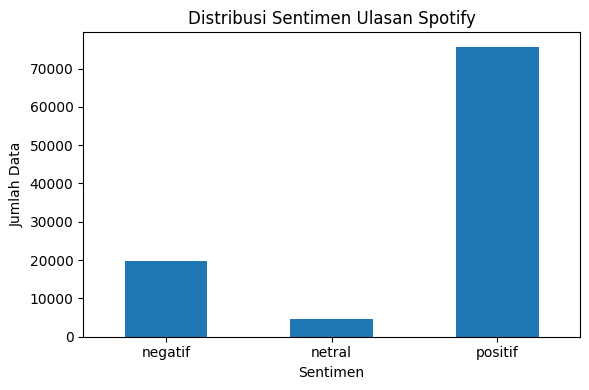

In [ ]:
# Cek jumlah data per rating
print("Distribusi Rating:")
print(df["rating"].value_counts().sort_index())

# Cek jumlah data per sentimen
print("Distribusi Sentimen:")
print(df["sentiment"].value_counts())

# Plot distribusi sentimen
plt.figure(figsize=(6, 4))
df["sentiment"].value_counts().reindex(["negatif", "netral", "positif"]).plot(kind="bar")
plt.title("Distribusi Sentimen Ulasan Spotify")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distribusi_sentimen.png", dpi=300)
plt.show()

## 7. Cleaning Teks

Cleaning dilakukan secara ringan karena model Transformer seperti IndoBERT masih membutuhkan konteks asli kalimat.  
Cleaning yang dilakukan:
- Mengubah teks menjadi lowercase.
- Menghapus URL.
- Menghapus mention dan hashtag simbol.
- Menghapus karakter yang terlalu tidak relevan.
- Menghapus spasi berlebih.

Cleaning tidak dibuat terlalu agresif agar makna kalimat tidak banyak hilang.

In [ ]:
def clean_text(text):
    """
    Membersihkan teks ulasan agar lebih konsisten sebelum masuk ke model.
    Cleaning dibuat ringan supaya konteks bahasa tetap terjaga untuk IndoBERT.
    """
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)       # hapus URL
    text = re.sub(r"@\w+", " ", text)                  # hapus mention
    text = re.sub(r"#", " ", text)                      # hapus simbol hashtag
    text = re.sub(r"[^a-zA-Z0-9\s.,!?]", " ", text)    # hapus karakter khusus berlebihan
    text = re.sub(r"\s+", " ", text).strip()           # hapus spasi berlebih
    return text

# Terapkan cleaning ke semua ulasan
df["clean_text"] = df["text"].apply(clean_text)

# Hapus data dengan teks kosong setelah cleaning
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

print("Shape setelah cleaning:", df.shape)
df[["text", "clean_text", "rating", "sentiment"]].head(10)

Shape setelah cleaning: (97969, 5)


,text,clean_text,rating,sentiment
0,suka banget sama ni app,suka banget sama ni app,5,positif
1,bgus,bgus,5,positif
2,ga bisa denger lagu JKT48 lagi gara² selalu di...,ga bisa denger lagu jkt48 lagi gara selalu di ...,1,negatif
3,lagunya bagus banget buat ngapa ngapain,lagunya bagus banget buat ngapa ngapain,5,positif
4,"kenapa sih, aku cuman bisa main 5 lagu doang? ...","kenapa sih, aku cuman bisa main 5 lagu doang? ...",1,negatif
5,mantap!!,mantap!!,5,positif
6,saya tidak bisa buka aplikasi nya saya harap d...,saya tidak bisa buka aplikasi nya saya harap d...,2,negatif
7,bagus sih lagu nya asik asik,bagus sih lagu nya asik asik,5,positif
8,bagus,bagus,5,positif
9,nemenin saat di perjalanan,nemenin saat di perjalanan,5,positif


## 8. Sampling Balanced 1510 Data per Kelas

Untuk eksperimen final, notebook ini mengambil maksimal **1510 data per kelas** agar distribusi kelas lebih seimbang.  
Total data yang digunakan sekitar 4530 data jika semua kelas memiliki minimal 1510 data.

Sampling balanced ini membantu mengurangi bias model terhadap kelas mayoritas.

In [ ]:
# Jumlah sampel maksimal per kelas untuk eksperimen final
SAMPLES_PER_CLASS = 300

# Ambil sampel balanced dari setiap kelas sentimen
df_sample = df.groupby("label", group_keys=False).apply(
    lambda x: x.sample(min(len(x), SAMPLES_PER_CLASS), random_state=SEED)
).reset_index(drop=True)

# Acak ulang urutan data setelah sampling
df_sample = df_sample.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Shape df_sample:", df_sample.shape)
print(df_sample["sentiment"].value_counts())

df_sample.head()

Shape df_sample: (900, 5)
sentiment
negatif    300
positif    300
netral     300
Name: count, dtype: int64


/tmp/ipykernel_2180/1813238918.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby("label", group_keys=False).apply(


,text,rating,label,sentiment,clean_text
0,terlalu banyak iklan,1,0,negatif,terlalu banyak iklan
1,Good,5,2,positif,good
2,Waktu di pakai lagunya suka mati sendiri minim...,1,0,negatif,waktu di pakai lagunya suka mati sendiri minim...
3,"you can put any ads, except Indian feminist po...",3,1,netral,"you can put any ads, except indian feminist po..."
4,Tolong hapus premiumnya,2,0,negatif,tolong hapus premiumnya


## 9. Split Data Train, Validation, dan Test

Data dibagi menjadi:
- 70% training
- 15% validation
- 15% test

Parameter `stratify` digunakan agar proporsi label tetap seimbang di setiap subset.

In [ ]:
# Split pertama: train 70%, temporary 30%
train_df, temp_df = train_test_split(
    df_sample,
    test_size=0.30,
    random_state=SEED,
    stratify=df_sample["label"]
)

# Split kedua: temporary dibagi menjadi validation 15% dan test 15%
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("Distribusi train:")
print(train_df["sentiment"].value_counts())
print("Distribusi validation:")
print(val_df["sentiment"].value_counts())
print("Distribusi test:")
print(test_df["sentiment"].value_counts())

Train: (630, 5)
Validation: (135, 5)
Test: (135, 5)
Distribusi train:
sentiment
positif    210
negatif    210
netral     210
Name: count, dtype: int64
Distribusi validation:
sentiment
netral     45
positif    45
negatif    45
Name: count, dtype: int64
Distribusi test:
sentiment
netral     45
negatif    45
positif    45
Name: count, dtype: int64


## 10. Baseline: TF-IDF + Logistic Regression

Baseline digunakan sebagai pembanding model utama.  
TF-IDF mengubah teks menjadi representasi numerik berdasarkan frekuensi kata, lalu Logistic Regression melakukan klasifikasi.

Baseline penting karena hasil IndoBERT perlu dibandingkan dengan pendekatan yang lebih sederhana.

In [ ]:
# TF-IDF mengubah teks menjadi fitur numerik
# ngram_range=(1, 2) berarti memakai unigram dan bigram
# max_features=10000 membatasi jumlah fitur agar training tetap ringan
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

# Fit TF-IDF hanya pada data train, lalu transform data test
X_train_tfidf = tfidf.fit_transform(train_df["clean_text"])
X_test_tfidf = tfidf.transform(test_df["clean_text"])

# Label target
y_train = train_df["label"]
y_test = test_df["label"]

# Logistic Regression sebagai classifier baseline
# class_weight='balanced' membantu jika distribusi kelas tidak benar-benar seimbang
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED,
    class_weight="balanced"
)

# Training baseline
baseline_model.fit(X_train_tfidf, y_train)

# Prediksi baseline pada test set
y_pred_baseline = baseline_model.predict(X_test_tfidf)

# Evaluasi baseline
baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline, average="macro")
baseline_precision = precision_score(y_test, y_pred_baseline, average="macro")
baseline_recall = recall_score(y_test, y_pred_baseline, average="macro")

print("=== Baseline: TF-IDF + Logistic Regression ===")
print("Accuracy :", baseline_acc)
print("F1 Macro:", baseline_f1)
print("Precision:", baseline_precision)
print("Recall   :", baseline_recall)

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_baseline,
    target_names=["negatif", "netral", "positif"]
))

=== Baseline: TF-IDF + Logistic Regression ===
Accuracy : 0.5407407407407407
F1 Macro: 0.5514497728089961
Precision: 0.5818326947637292
Recall   : 0.5407407407407407
Classification Report:
              precision    recall  f1-score   support

     negatif       0.45      0.58      0.50        45
      netral       0.42      0.42      0.42        45
     positif       0.88      0.62      0.73        45

    accuracy                           0.54       135
   macro avg       0.58      0.54      0.55       135
weighted avg       0.58      0.54      0.55       135



## 11. Confusion Matrix Baseline

Confusion matrix menunjukkan jumlah prediksi benar dan salah untuk setiap kelas.  
Baris menunjukkan label sebenarnya, sedangkan kolom menunjukkan label prediksi.

<Figure size 600x500 with 0 Axes>

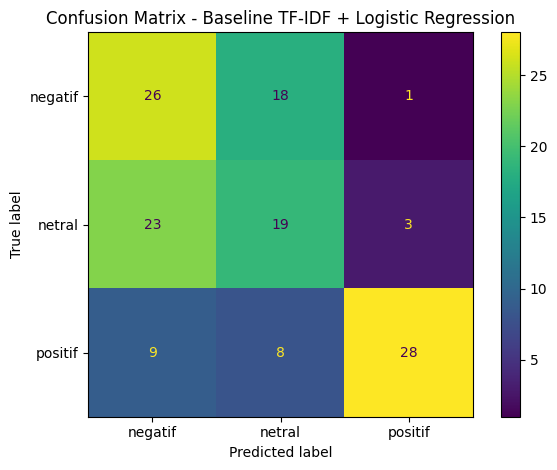

In [ ]:
# Buat dan tampilkan confusion matrix baseline
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=["negatif", "netral", "positif"]
)
disp.plot(values_format="d")
plt.title("Confusion Matrix - Baseline TF-IDF + Logistic Regression")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_baseline.png", dpi=300)
plt.show()

## 12. Persiapan Dataset untuk IndoBERT

IndoBERT membutuhkan input dalam bentuk token.  
Bagian ini mempersiapkan tokenizer dan mengubah dataframe menjadi format Hugging Face Dataset.

In [ ]:
# Model utama berbasis Transformer untuk Bahasa Indonesia
MODEL_NAME = "indobenchmark/indobert-base-p1"

# Tokenizer mengubah teks menjadi token ID yang bisa diproses oleh BERT
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Ubah dataframe menjadi Hugging Face Dataset
# preserve_index=False supaya index pandas tidak ikut masuk ke dataset
train_dataset = Dataset.from_pandas(train_df[["clean_text", "label"]], preserve_index=False)
val_dataset = Dataset.from_pandas(val_df[["clean_text", "label"]], preserve_index=False)
test_dataset = Dataset.from_pandas(test_df[["clean_text", "label"]], preserve_index=False)

print(train_dataset)
print(val_dataset)
print(test_dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Dataset({
    features: ['clean_text', 'label'],
    num_rows: 630
})
Dataset({
    features: ['clean_text', 'label'],
    num_rows: 135
})
Dataset({
    features: ['clean_text', 'label'],
    num_rows: 135
})


## 13. Tokenisasi Dataset

Tokenisasi mengubah teks menjadi format input yang dibutuhkan BERT:
- `input_ids`: representasi token.
- `attention_mask`: penanda token mana yang perlu diperhatikan model.

Parameter `max_length=128` dipakai agar training lebih ringan dan cukup untuk sebagian besar ulasan pendek.

In [ ]:
def tokenize_function(batch):
    """
    Fungsi tokenisasi untuk mengubah clean_text menjadi input BERT.
    padding='max_length' membuat semua input memiliki panjang yang sama.
    truncation=True memotong teks yang terlalu panjang.
    """
    return tokenizer(
        batch["clean_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Terapkan tokenisasi ke train, validation, dan test dataset
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Hapus kolom teks asli karena model hanya membutuhkan token dan label
train_dataset = train_dataset.remove_columns(["clean_text"])
val_dataset = val_dataset.remove_columns(["clean_text"])
test_dataset = test_dataset.remove_columns(["clean_text"])

# Set format dataset agar kompatibel dengan PyTorch
train_dataset.set_format("torch")
val_dataset.set_format("torch")
test_dataset.set_format("torch")

train_dataset[0]

Map:   0%|          | 0/630 [00:00<?, ? examples/s]

Map:   0%|          | 0/135 [00:00<?, ? examples/s]

Map:   0%|          | 0/135 [00:00<?, ? examples/s]

{'label': tensor(2),
 'input_ids': tensor([   2, 5159,    3,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]),
 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

## 14. Fungsi Evaluasi dan Helper Trainer

Bagian ini berisi:
- Fungsi `compute_metrics` untuk menghitung accuracy dan F1-macro.
- Fungsi `build_trainer` agar kompatibel dengan beberapa versi library `transformers`.
- Fungsi `run_indobert_experiment` untuk menjalankan eksperimen IndoBERT dengan konfigurasi berbeda.

In [ ]:
def compute_metrics(eval_pred):
    """
    Fungsi evaluasi untuk Trainer Hugging Face.
    Output utama yang dipakai adalah accuracy dan F1-macro.
    F1-macro penting karena menghitung rata-rata performa setiap kelas secara seimbang.
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }


def build_trainer(model, training_args, train_dataset, val_dataset, tokenizer):
    """
    Helper untuk membuat Trainer.
    Beberapa versi transformers memakai processing_class, beberapa versi lama memakai tokenizer.
    Fungsi ini membuat notebook lebih aman dijalankan di berbagai versi transformers.
    """
    trainer_kwargs = {
        "model": model,
        "args": training_args,
        "train_dataset": train_dataset,
        "eval_dataset": val_dataset,
        "compute_metrics": compute_metrics,
    }

    trainer_signature = inspect.signature(Trainer.__init__).parameters
    if "processing_class" in trainer_signature:
        trainer_kwargs["processing_class"] = tokenizer
    elif "tokenizer" in trainer_signature:
        trainer_kwargs["tokenizer"] = tokenizer

    return Trainer(**trainer_kwargs)


def run_indobert_experiment(run_name, learning_rate=2e-5, num_train_epochs=3, batch_size=8):
    """
    Menjalankan satu eksperimen fine-tuning IndoBERT.
    Setiap eksperimen reload model baru agar hasil antar run tidak saling mempengaruhi.
    """
    print(f"===== Running experiment: {run_name} =====")
    print(f"LR={learning_rate}, Epoch={num_train_epochs}, Batch size={batch_size}")

    # Load model IndoBERT untuk sequence classification 3 kelas
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3
    )

    # TrainingArguments berisi konfigurasi training
    training_args = TrainingArguments(
        output_dir=str(OUTPUT_DIR / run_name),
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_train_epochs,
        weight_decay=0.01,
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        seed=SEED,
        report_to="none",
    )

    # Buat trainer
    trainer = build_trainer(
        model=model,
        training_args=training_args,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        tokenizer=tokenizer
    )

    # Training model
    trainer.train()

    # Evaluasi pada test set
    predictions = trainer.predict(test_dataset)
    logits = predictions.predictions
    y_pred = np.argmax(logits, axis=1)
    y_true = predictions.label_ids

    # Hitung metrik test
    metrics = {
        "Model": run_name,
        "Learning Rate": learning_rate,
        "Epoch": num_train_epochs,
        "Batch Size": batch_size,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision-Macro": precision_score(y_true, y_pred, average="macro"),
        "Recall-Macro": recall_score(y_true, y_pred, average="macro"),
        "F1-Macro": f1_score(y_true, y_pred, average="macro"),
    }

    print(f"=== Test Result: {run_name} ===")
    print(json.dumps(metrics, indent=2))
    print("Classification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["negatif", "netral", "positif"]
    ))

    return trainer, y_true, y_pred, metrics

## 15. Eksperimen 1: IndoBERT Final Run

Eksperimen utama menggunakan:
- learning rate: `2e-5`
- epoch: `3`
- batch size: `8`

Ini menjadi model utama yang dibandingkan dengan baseline TF-IDF + Logistic Regression.

In [ ]:
# Eksperimen utama IndoBERT
trainer_indobert_main, y_true_main, y_pred_main, metrics_main = run_indobert_experiment(
    run_name="IndoBERT_Main_LR2e-5_Epoch3",
    learning_rate=2e-5,
    num_train_epochs=3,
    batch_size=8
)

===== Running experiment: IndoBERT_Main_LR2e-5_Epoch3 =====
LR=2e-05, Epoch=3, Batch size=8


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

=== Test Result: IndoBERT_Main_LR2e-5_Epoch3 ===
{
  "Model": "IndoBERT_Main_LR2e-5_Epoch3",
  "Learning Rate": 2e-05,
  "Epoch": 3,
  "Batch Size": 8,
  "Accuracy": 0.5851851851851851,
  "Precision-Macro": 0.5921459492888065,
  "Recall-Macro": 0.5851851851851851,
  "F1-Macro": 0.5879984941786817
}
Classification Report:
              precision    recall  f1-score   support

     negatif       0.51      0.56      0.53        45
      netral       0.41      0.40      0.40        45
     positif       0.86      0.80      0.83        45

    accuracy                           0.59       135
   macro avg       0.59      0.59      0.59       135
weighted avg       0.59      0.59      0.59       135



## 16. Eksperimen 2: IndoBERT Tuning Run

Eksperimen tuning dilakukan untuk menunjukkan adanya iterasi hyperparameter.  
Pada run ini, learning rate diturunkan menjadi `1e-5` dengan epoch dan batch size yang sama.

Tujuannya adalah melihat apakah learning rate yang lebih kecil memberi training yang lebih stabil.

In [ ]:
# Eksperimen tuning IndoBERT
trainer_indobert_tuned, y_true_tuned, y_pred_tuned, metrics_tuned = run_indobert_experiment(
    run_name="IndoBERT_Tuned_LR1e-5_Epoch3",
    learning_rate=1e-5,
    num_train_epochs=3,
    batch_size=8
)

===== Running experiment: IndoBERT_Tuned_LR1e-5_Epoch3 =====
LR=1e-05, Epoch=3, Batch size=8


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.927783,0.807934,0.651852,0.656530
2,0.733417,0.798484,0.622222,0.614275
3,0.626305,0.800525,0.637037,0.633539


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

=== Test Result: IndoBERT_Tuned_LR1e-5_Epoch3 ===
{
  "Model": "IndoBERT_Tuned_LR1e-5_Epoch3",
  "Learning Rate": 1e-05,
  "Epoch": 3,
  "Batch Size": 8,
  "Accuracy": 0.6148148148148148,
  "Precision-Macro": 0.6300827423167848,
  "Recall-Macro": 0.6148148148148148,
  "F1-Macro": 0.6212184546562898
}
Classification Report:
              precision    recall  f1-score   support

     negatif       0.53      0.56      0.54        45
      netral       0.46      0.49      0.47        45
     positif       0.90      0.80      0.85        45

    accuracy                           0.61       135
   macro avg       0.63      0.61      0.62       135
weighted avg       0.63      0.61      0.62       135



## 17. Perbandingan Semua Model

Bagian ini membandingkan:
1. Baseline TF-IDF + Logistic Regression.
2. IndoBERT main run.
3. IndoBERT tuning run.

Model terbaik dipilih berdasarkan **F1-Macro**, karena metrik ini memperhatikan performa semua kelas secara seimbang.

In [ ]:
# Gabungkan hasil baseline dan IndoBERT ke dataframe
results_df = pd.DataFrame([
    {
        "Model": "TF-IDF + Logistic Regression",
        "Learning Rate": None,
        "Epoch": None,
        "Batch Size": None,
        "Accuracy": baseline_acc,
        "Precision-Macro": baseline_precision,
        "Recall-Macro": baseline_recall,
        "F1-Macro": baseline_f1,
    },
    metrics_main,
    metrics_tuned,
])

# Urutkan berdasarkan F1-Macro tertinggi
results_df = results_df.sort_values(by="F1-Macro", ascending=False).reset_index(drop=True)

# Simpan hasil perbandingan ke CSV
results_df.to_csv(OUTPUT_DIR / "comparison_results.csv", index=False)

results_df

,Model,Learning Rate,Epoch,Batch Size,Accuracy,Precision-Macro,Recall-Macro,F1-Macro
0,IndoBERT_Tuned_LR1e-5_Epoch3,0.00001,3.0,8.0,0.614815,0.630083,0.614815,0.621218
1,IndoBERT_Main_LR2e-5_Epoch3,0.00002,3.0,8.0,0.585185,0.592146,0.585185,0.587998
2,TF-IDF + Logistic Regression,NaN,NaN,NaN,0.540741,0.581833,0.540741,0.551450


## 18. Visualisasi Perbandingan Model

Grafik ini digunakan untuk laporan/presentasi agar perbandingan model mudah dilihat.

<Figure size 900x500 with 0 Axes>

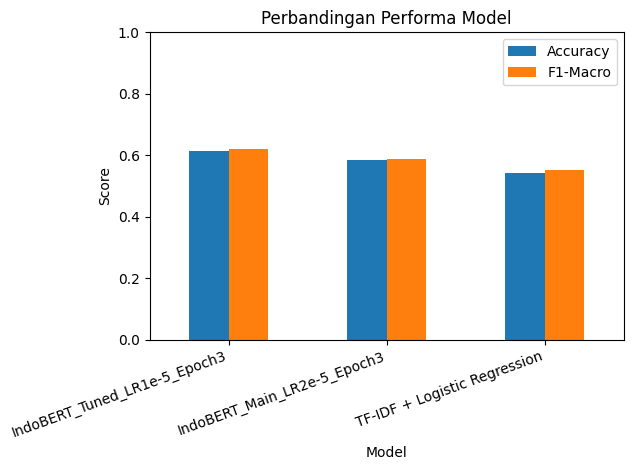

In [ ]:
# Visualisasi Accuracy dan F1-Macro untuk semua model
plot_df = results_df.set_index("Model")[["Accuracy", "F1-Macro"]]

plt.figure(figsize=(9, 5))
plot_df.plot(kind="bar")
plt.title("Perbandingan Performa Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison.png", dpi=300)
plt.show()

In [ ]:
# Tampilkan tabel hasil dengan 4 angka desimal
display(
    results_df.style
    .format({
        "Accuracy": "{:.4f}",
        "F1-Macro": "{:.4f}"
    })
    .set_caption("Tabel Perbandingan Performa Model")
)

,Model,Learning Rate,Epoch,Batch Size,Accuracy,Precision-Macro,Recall-Macro,F1-Macro
0,IndoBERT_Tuned_LR1e-5_Epoch3,0.000010,3.000000,8.000000,0.6148,0.630083,0.614815,0.6212
1,IndoBERT_Main_LR2e-5_Epoch3,0.000020,3.000000,8.000000,0.5852,0.592146,0.585185,0.5880
2,TF-IDF + Logistic Regression,nan,nan,nan,0.5407,0.581833,0.540741,0.5514


## 19. Pilih Model IndoBERT Terbaik

Bagian ini memilih run IndoBERT terbaik berdasarkan F1-Macro.  
Model terbaik akan digunakan untuk confusion matrix, error analysis, demo prediksi, dan penyimpanan model akhir.

In [ ]:
# Pilih model IndoBERT terbaik berdasarkan F1-Macro
if metrics_main["F1-Macro"] >= metrics_tuned["F1-Macro"]:
    best_trainer = trainer_indobert_main
    best_y_true = y_true_main
    best_y_pred = y_pred_main
    best_run_name = metrics_main["Model"]
    best_metrics = metrics_main
else:
    best_trainer = trainer_indobert_tuned
    best_y_true = y_true_tuned
    best_y_pred = y_pred_tuned
    best_run_name = metrics_tuned["Model"]
    best_metrics = metrics_tuned

print("Best IndoBERT Run:", best_run_name)
print(json.dumps(best_metrics, indent=2))

Best IndoBERT Run: IndoBERT_Tuned_LR1e-5_Epoch3
{
  "Model": "IndoBERT_Tuned_LR1e-5_Epoch3",
  "Learning Rate": 1e-05,
  "Epoch": 3,
  "Batch Size": 8,
  "Accuracy": 0.6148148148148148,
  "Precision-Macro": 0.6300827423167848,
  "Recall-Macro": 0.6148148148148148,
  "F1-Macro": 0.6212184546562898
}


## 20. Confusion Matrix Model IndoBERT Terbaik

Confusion matrix ini digunakan untuk melihat kelas mana yang paling sering tertukar oleh model.

<Figure size 600x500 with 0 Axes>

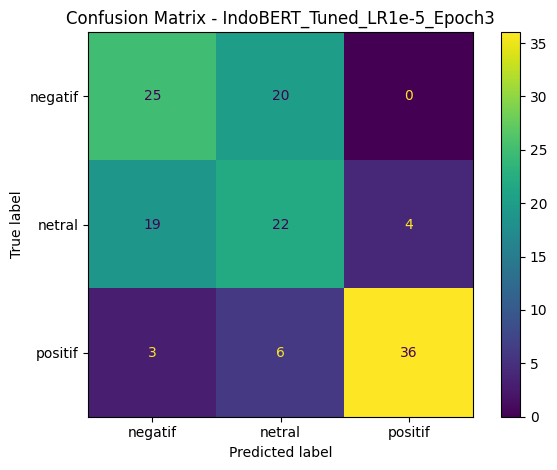

In [ ]:
# Confusion matrix untuk model IndoBERT terbaik
cm_indobert = confusion_matrix(best_y_true, best_y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_indobert,
    display_labels=["negatif", "netral", "positif"]
)
disp.plot(values_format="d")
plt.title(f"Confusion Matrix - {best_run_name}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_best_indobert.png", dpi=300)
plt.show()

## 21. Error Analysis

Error analysis dilakukan dengan mengambil contoh prediksi yang salah.  
Bagian ini penting untuk menemukan keterbatasan model, seperti:
- Ulasan terlalu pendek.
- Ulasan ambigu.
- Rating tidak konsisten dengan isi teks.
- Kalimat mengandung slang atau bahasa tidak formal.

In [ ]:
# Buat dataframe hasil prediksi pada test set
test_result_df = test_df.copy().reset_index(drop=True)
test_result_df["true_label"] = best_y_true
test_result_df["pred_label"] = best_y_pred

test_result_df["true_sentiment"] = test_result_df["true_label"].map(label_map)
test_result_df["pred_sentiment"] = test_result_df["pred_label"].map(label_map)

# Ambil data yang salah prediksi
wrong_preds = test_result_df[test_result_df["true_label"] != test_result_df["pred_label"]].copy()

# Simpan error analysis ke CSV
wrong_preds[["clean_text", "rating", "true_sentiment", "pred_sentiment"]].to_csv(
    OUTPUT_DIR / "error_analysis_indobert.csv",
    index=False
)

print("Jumlah prediksi salah:", len(wrong_preds))
wrong_preds[["clean_text", "rating", "true_sentiment", "pred_sentiment"]].head(15)

Jumlah prediksi salah: 52


,clean_text,rating,true_sentiment,pred_sentiment
4,skrg banyak banget iklan nya bisa 1 4 iklan,1,negatif,netral
18,"aplikasi musik paling kikir, pelitnya ngelebih...",3,netral,negatif
20,kenapa ini masa tiba harus premium dulu biar b...,1,negatif,netral
21,they support genocide,1,negatif,netral
29,selalu muncul iklan,3,netral,negatif
30,jangn terlalu banyak iklan dong kurangi iklan ...,1,negatif,netral
31,sebelum2 nya oke kenapa sekarang sportif ngak ...,1,negatif,netral
34,enak banget kalau lagi gabut,5,positif,netral
36,"semua ae premium, muak banget gw ajg.",3,netral,negatif
39,ada opsi setengah bintang gak yah? yaudah kala...,1,negatif,netral


## 22. Analisis Singkat Kesalahan Model

Cell ini menghitung pola kesalahan, misalnya kelas mana yang paling sering salah diprediksi menjadi kelas lain.

In [ ]:
# Tabel jenis kesalahan: true sentiment vs predicted sentiment
error_pattern = pd.crosstab(
    wrong_preds["true_sentiment"],
    wrong_preds["pred_sentiment"],
    rownames=["True Sentiment"],
    colnames=["Predicted Sentiment"]
)

# Simpan pola kesalahan
error_pattern.to_csv(OUTPUT_DIR / "error_pattern_indobert.csv")

error_pattern

Predicted Sentiment,negatif,netral,positif
True Sentiment,,,
negatif,0,20,0
netral,19,0,4
positif,3,6,0


## 23. Fungsi Demo Prediksi Manual

Fungsi ini digunakan untuk demo saat presentasi.  
User dapat memasukkan teks ulasan, lalu model IndoBERT terbaik akan memprediksi sentimennya.

In [ ]:
def predict_sentiment(text):
    """
    Fungsi demo untuk memprediksi sentimen dari satu teks ulasan.
    Output berupa label: negatif, netral, atau positif.
    """
    # Bersihkan teks dengan fungsi cleaning yang sama seperti data training
    cleaned = clean_text(text)

    # Tokenisasi input teks
    inputs = tokenizer(
        cleaned,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )

    # Pindahkan input dan model ke device yang tersedia
    model = best_trainer.model
    model.to(DEVICE)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    # Prediksi tanpa menghitung gradient
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        pred_id = torch.argmax(outputs.logits, dim=1).item()

    return label_map[pred_id]

# Contoh demo prediksi manual
examples = [
    "Aplikasinya bagus banget, lagu lengkap dan mudah digunakan",
    "Sering error dan lag, padahal sudah premium",
    "Lumayan sih tapi iklannya terlalu banyak",
    "Tidak bisa login setelah update terbaru",
    "Saya suka fitur playlist dan rekomendasinya",
]

for text in examples:
    print(f"{text} => {predict_sentiment(text)}")

Aplikasinya bagus banget, lagu lengkap dan mudah digunakan => positif
Sering error dan lag, padahal sudah premium => negatif
Lumayan sih tapi iklannya terlalu banyak => netral
Tidak bisa login setelah update terbaru => negatif
Saya suka fitur playlist dan rekomendasinya => positif


## 24. Simpan Model, Tokenizer, dan Artefak Hasil

Bagian ini menyimpan:
- Model IndoBERT terbaik.
- Tokenizer.
- Hasil eksperimen dalam CSV.
- Error analysis.
- Gambar confusion matrix dan grafik perbandingan.

Folder output dapat diunduh atau dimasukkan ke GitHub/Google Drive.

In [ ]:
# Folder penyimpanan model akhir
MODEL_SAVE_DIR = OUTPUT_DIR / "saved_best_indobert_spotify_sentiment"
MODEL_SAVE_DIR.mkdir(exist_ok=True)

# Simpan model dan tokenizer
best_trainer.save_model(str(MODEL_SAVE_DIR))
tokenizer.save_pretrained(str(MODEL_SAVE_DIR))

# Simpan metadata eksperimen ringkas
experiment_summary = {
    "dataset": "Spotify Reviews - Indonesia (Google Play Store)",
    "labeling_rule": {
        "rating_1_2": "negatif",
        "rating_3": "netral",
        "rating_4_5": "positif"
    },
    "samples_per_class": SAMPLES_PER_CLASS,
    "best_indobert_run": best_run_name,
    "best_metrics": best_metrics,
    "all_results": results_df.to_dict(orient="records")
}

with open(OUTPUT_DIR / "experiment_summary.json", "w", encoding="utf-8") as f:
    json.dump(experiment_summary, f, indent=2, ensure_ascii=False)

print("Model dan hasil eksperimen berhasil disimpan di folder:", OUTPUT_DIR)
print("Model terbaik disimpan di:", MODEL_SAVE_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model dan hasil eksperimen berhasil disimpan di folder: outputs
Model terbaik disimpan di: outputs/saved_best_indobert_spotify_sentiment


## 25. Zip Output untuk Diunduh

Cell ini membuat file ZIP berisi seluruh hasil eksperimen, termasuk CSV, gambar, summary JSON, dan model tersimpan.

In [ ]:
# Zip seluruh folder output agar mudah diunduh dari Colab
#!zip -r outputs_spotify_indobert.zip outputs

## 26. Kesimpulan Sementara

Notebook ini telah mengimplementasikan pipeline lengkap untuk proyek akhir:

1. Dataset Spotify Reviews Indonesia berhasil dimuat.
2. Label sentimen dibuat dari rating pengguna.
3. Baseline TF-IDF + Logistic Regression telah dilatih.
4. Model utama IndoBERT telah di-fine-tune.
5. Minimal satu eksperimen tuning IndoBERT telah dilakukan.
6. Hasil semua model dibandingkan menggunakan Accuracy dan F1-Macro.
7. Error analysis dilakukan untuk melihat contoh prediksi yang salah.
8. Fungsi demo prediksi manual telah tersedia.
9. Model dan hasil eksperimen telah disimpan.

Untuk laporan akhir, hasil pada `comparison_results.csv`, `confusion_matrix_best_indobert.png`, `model_comparison.png`, dan `error_analysis_indobert.csv` dapat digunakan sebagai bahan pembahasan.

In [ ]:
# ============================================================
# WEB DEMO SEDERHANA DENGAN GRADIO
# Model: Fine-tuned IndoBERT untuk Sentiment Analysis Spotify
# ============================================================

# Install Gradio untuk membuat web demo sederhana di Colab
!pip install gradio -q

# Import library yang dibutuhkan
import torch
import torch.nn.functional as F
import gradio as gr
import re
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ============================================================
# 1. LOAD MODEL YANG SUDAH DISIMPAN
# ============================================================

# Path model sesuai dengan folder save kamu
MODEL_PATH = Path("outputs/saved_best_indobert_spotify_sentiment")

# Load tokenizer dan model dari folder lokal
tokenizer_demo = AutoTokenizer.from_pretrained(str(MODEL_PATH))
model_demo = AutoModelForSequenceClassification.from_pretrained(str(MODEL_PATH))

# Gunakan GPU kalau tersedia, kalau tidak pakai CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Pindahkan model ke device
model_demo.to(device)

# Set model ke mode evaluasi, bukan training
model_demo.eval()

print("Model berhasil dimuat dari:", MODEL_PATH)
print("Device yang digunakan:", device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model berhasil dimuat dari: outputs/saved_best_indobert_spotify_sentiment
Device yang digunakan: cuda


In [ ]:
# ============================================================
# 2. FUNGSI CLEANING TEKS
# ============================================================

def clean_text_demo(text):
    """
    Fungsi ini digunakan untuk membersihkan teks input user.
    Cleaning dibuat mirip dengan preprocessing saat training.
    """

    # Ubah input menjadi string dan lowercase
    text = str(text).lower()

    # Hapus URL
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Hapus mention seperti @user
    text = re.sub(r"@\w+", " ", text)

    # Hapus tanda hashtag, tetapi isi katanya tetap dibiarkan
    text = re.sub(r"#", " ", text)

    # Hapus karakter aneh, tetapi tetap simpan huruf, angka, spasi, dan tanda baca umum
    text = re.sub(r"[^a-zA-Z0-9\s.,!?]", " ", text)

    # Rapikan spasi berlebih
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Mapping label sesuai training:
# 0 = negatif, 1 = netral, 2 = positif
label_map_demo = {
    0: "Negatif",
    1: "Netral",
    2: "Positif"
}

In [ ]:
# ============================================================
# 3. FUNGSI PREDIKSI SENTIMEN
# ============================================================

def predict_sentiment_demo(review_text):
    """
    Fungsi utama untuk demo web.
    Input  : teks ulasan Spotify
    Output : label sentimen + confidence score
    """

    # Kalau input kosong, kembalikan pesan error ringan
    if review_text is None or str(review_text).strip() == "":
        return "Input kosong", 0.0, {
            "Negatif": 0.0,
            "Netral": 0.0,
            "Positif": 0.0
        }

    # Bersihkan teks menggunakan fungsi cleaning
    cleaned_text = clean_text_demo(review_text)

    # Tokenisasi teks agar bisa dibaca oleh IndoBERT
    inputs = tokenizer_demo(
        cleaned_text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )

    # Pindahkan input ke GPU/CPU yang sama dengan model
    inputs = {key: value.to(device) for key, value in inputs.items()}

    # Prediksi tanpa gradient agar lebih ringan dan cepat
    with torch.no_grad():
        outputs = model_demo(**inputs)
        logits = outputs.logits

        # Softmax mengubah logits menjadi probabilitas
        probabilities = F.softmax(logits, dim=1).cpu().numpy()[0]

    # Ambil label dengan probabilitas tertinggi
    predicted_id = int(probabilities.argmax())
    predicted_label = label_map_demo[predicted_id]
    confidence = float(probabilities[predicted_id])

    # Dictionary probabilitas untuk ditampilkan di Gradio Label
    probability_dict = {
        "Negatif": float(probabilities[0]),
        "Netral": float(probabilities[1]),
        "Positif": float(probabilities[2])
    }

    return predicted_label, confidence, probability_dict

In [ ]:
# ============================================================
# 4. BUAT WEB DEMO GRADIO
# ============================================================

demo = gr.Interface(
    fn=predict_sentiment_demo,

    # Input berupa textbox untuk memasukkan ulasan
    inputs=gr.Textbox(
        lines=5,
        placeholder="Contoh: Aplikasinya bagus banget, lagu lengkap, tapi kadang suka error...",
        label="Masukkan Ulasan Spotify"
    ),

    # Output:
    # 1. Label prediksi utama
    # 2. Confidence score
    # 3. Probabilitas tiap kelas
    outputs=[
        gr.Textbox(label="Prediksi Sentimen"),
        gr.Number(label="Confidence Score"),
        gr.Label(num_top_classes=3, label="Probabilitas Tiap Kelas")
    ],

    title="Demo Klasifikasi Sentimen Ulasan Spotify",

    description=(
        "Demo sederhana berbasis web untuk mengklasifikasikan sentimen ulasan aplikasi Spotify "
        "menggunakan model IndoBERT berbasis Transformer. "
        "Input berupa teks ulasan, lalu model akan memprediksi sentimen: Negatif, Netral, atau Positif."
    ),

    examples=[
        ["Aplikasinya bagus banget, lagu lengkap dan mudah digunakan."],
        ["Sering error dan banyak iklan, padahal saya sudah premium."],
        ["Lumayan bagus, tapi kadang suka lag setelah update."],
        ["Tidak bisa login setelah update terbaru."],
        ["Saya suka rekomendasi lagu dan playlist-nya."],
        ["Kebanyakan iklan, jadi kurang nyaman dipakai."]
    ],

    theme="soft"
)

# share=True akan membuat link publik sementara dari Colab
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3e30be8c37820b66d8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
